# 05. Reduksi Dimensi dengan Principal Component Analysis (PCA)

Notebook ini khusus untuk tahap **Reduksi Dimensi** dari matriks TF-IDF (`hasil_tfidf.csv`) menggunakan **PCA**.

### Tujuan PCA:
- Mengurangi ribuan fitur kata (dimensi tinggi) menjadi 20 komponen utama (*Principal Components*).
- Mempertahankan varians/informasi penting terbanyak dalam data.
- Mempermudah visualisasi data teks dan komputasi model.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display

## 2. Membaca Dataset TF-IDF
Membaca hasil representasi TF-IDF dari file `hasil_tfidf.csv`.

In [2]:
df_tfidf = pd.read_csv("hasil_tfidf.csv")

# Pisahkan metadata (id, label) dan matriks fitur TF-IDF
ids = df_tfidf["id"]
labels = df_tfidf["label"]
X = df_tfidf.drop(columns=["id", "label"]).values

print("Bentuk Matriks Fitur TF-IDF:", X.shape)

Bentuk Matriks Fitur TF-IDF: (200, 6269)


## 3. Penerapan PCA (20 Komponen Utama)
Mereduksi matriks TF-IDF menjadi 20 komponen utama (`n_components=20`).

In [3]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X)

print("=== Perbandingan Dimensi Data ===")
print(f"Sebelum Reduksi (TF-IDF asli): {X.shape}")
print(f"Setelah Reduksi (PCA)        : {X_pca.shape}")

=== Perbandingan Dimensi Data ===
Sebelum Reduksi (TF-IDF asli): (200, 6269)
Setelah Reduksi (PCA)        : (200, 20)


## 4. Analisis Explained Variance
Menganalisis seberapa besar rasio varians informasi data asli yang mampu ditangkap oleh setiap komponen PCA.

,Komponen,Explained_Variance,Cumulative_Variance
0,PC1,0.055616,0.055616
1,PC2,0.028864,0.084480
2,PC3,0.028294,0.112775
3,PC4,0.023279,0.136054
4,PC5,0.019118,0.155172
5,PC6,0.017507,0.172679
6,PC7,0.016024,0.188703
7,PC8,0.015582,0.204285
8,PC9,0.015033,0.219318
9,PC10,0.013572,0.232890


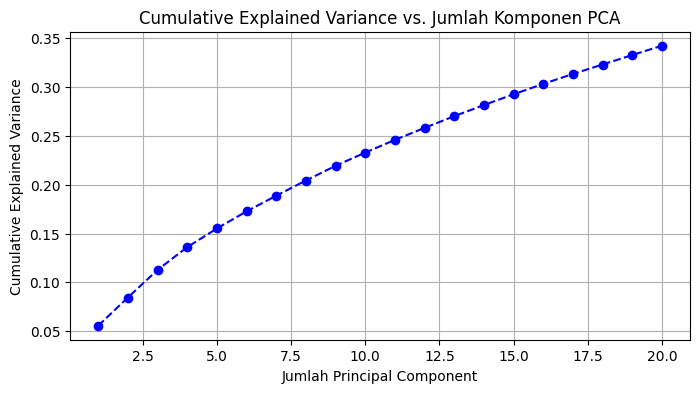

In [4]:
var_rasio = pca.explained_variance_ratio_
var_kumulatif = np.cumsum(var_rasio)

df_var = pd.DataFrame({
    "Komponen": [f"PC{i+1}" for i in range(len(var_rasio))],
    "Explained_Variance": var_rasio,
    "Cumulative_Variance": var_kumulatif
})
display(df_var.head(10))

# Visualisasi Scree Plot Kumulatif
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_kumulatif) + 1), var_kumulatif, marker="o", linestyle="--", color="b")
plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Jumlah Komponen PCA")
plt.grid(True)
plt.show()

## 5. Visualisasi 2D Hasil PCA
Memetakan dokumen berita ke bidang 2D menggunakan PC1 dan PC2 untuk melihat pemisahan antara topik Sport (1) dan Finance (2).

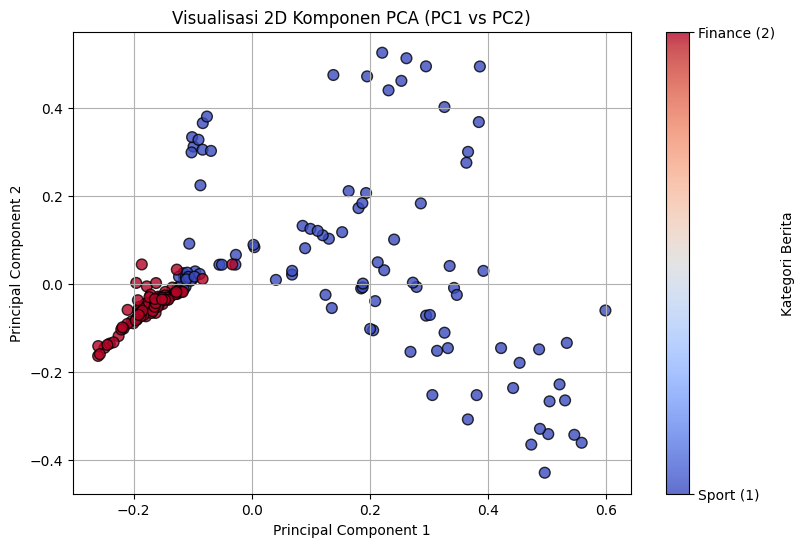

In [5]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap="coolwarm",
    s=60, alpha=0.8, edgecolors="k"
)
plt.title("Visualisasi 2D Komponen PCA (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
cbar = plt.colorbar(scatter, ticks=[1, 2])
cbar.ax.set_yticklabels(["Sport (1)", "Finance (2)"])
cbar.set_label("Kategori Berita")
plt.grid(True)
plt.show()

## 6. Evaluasi Klasifikasi Berbasis Centroid
Menguji apakah pemisahan kategori hasil representasi fitur dapat mengklasifikasikan data testing dengan benar.

In [6]:
# Pembagian 160 training dan 40 testing (sama dengan tahap TF-IDF)
idx_train = list(range(0, 80)) + list(range(100, 180))
idx_test = [i for i in range(len(labels)) if i not in idx_train]

# Hitung centroid tiap kategori dari data training
centroid_sport = X[idx_train][labels.iloc[idx_train].values == 1].mean(axis=0)
centroid_finance = X[idx_train][labels.iloc[idx_train].values == 2].mean(axis=0)

# Prediksi berdasarkan jarak terdekat ke centroid
dist_sport = np.linalg.norm(X[idx_test] - centroid_sport, axis=1)
dist_finance = np.linalg.norm(X[idx_test] - centroid_finance, axis=1)
prediksi = np.where(dist_sport <= dist_finance, 1, 2)

akurasi = (prediksi == labels.iloc[idx_test].values).mean()
print(f"Akurasi Klasifikasi Centroid pada Data Testing: {akurasi * 100:.2f}%")

Akurasi Klasifikasi Centroid pada Data Testing: 95.00%


## 7. Menyimpan Hasil PCA ke CSV

In [7]:
kolom_pca = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=kolom_pca)
df_pca.insert(0, "label", labels)
df_pca.insert(0, "id", ids)

df_pca.to_csv("hasil_pca2.csv", index=False)
print("Hasil PCA berhasil disimpan ke 'hasil_pca2.csv'.")
display(df_pca.head())

Hasil PCA berhasil disimpan ke 'hasil_pca2.csv'.


,id,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,SP001,1,0.180534,0.172703,-0.137537,-0.046661,-0.043288,-0.292432,-0.017877,0.449575,...,0.165050,0.063250,0.007462,0.051374,0.054274,-0.006297,-0.023226,0.021589,-0.119495,0.013790
1,SP002,1,0.305518,-0.252049,0.007800,-0.285470,0.016916,0.057499,-0.154388,0.079346,...,0.011613,-0.009267,-0.028012,0.012627,-0.010129,0.016407,-0.042168,0.035143,-0.045851,0.022357
2,SP003,1,0.286000,0.183361,-0.146817,-0.109974,-0.004756,-0.213904,-0.029000,0.384886,...,0.175877,0.084569,0.017562,0.063622,0.080177,-0.037609,-0.047339,0.027077,-0.087375,0.002115
3,SP004,1,0.193349,0.206876,-0.109453,-0.002961,-0.033024,-0.302167,-0.014675,0.475222,...,0.142821,0.084312,-0.015349,0.064802,0.020529,-0.014244,-0.028736,-0.013059,-0.080211,-0.050543
4,SP005,1,-0.114728,0.014352,0.040535,-0.004952,-0.070150,-0.053060,-0.041639,-0.040038,...,-0.056965,-0.036385,0.016713,-0.104298,-0.025188,-0.078206,0.024082,-0.003561,-0.078637,0.054935
